# LivreNet - Analyse Data Marketing

## Chargement des librairies

In [9]:
#importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr, mannwhitneyu, kruskal

## Analyse descriptive et nettoyage de la donnée

### 1. Table customers

In [209]:
#chargement de la table customers
customers = pd.read_csv('customers.csv')
customers

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
...,...,...,...
8618,c_7920,m,1956
8619,c_7403,f,1970
8620,c_5119,m,1974
8621,c_5643,f,1968


In [13]:
#afficher les caractéristiques des variables, pour comprendre la donnée
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


In [14]:
#Vérifier la présence de doublons sur les potentielles clés primaires : customers
customers['client_id'].duplicated().sum()

0

In [15]:
#vérification des doublons dans la table customers
customers.duplicated().sum()

0

In [16]:
#Convertir la colonne 'birth' en type date
customers['birth'] = pd.to_datetime(customers['birth'], format='%Y')
customers

,client_id,sex,birth
0,c_4410,f,1967-01-01
1,c_7839,f,1975-01-01
2,c_1699,f,1984-01-01
3,c_5961,f,1962-01-01
4,c_5320,m,1943-01-01
...,...,...,...
8618,c_7920,m,1956-01-01
8619,c_7403,f,1970-01-01
8620,c_5119,m,1974-01-01
8621,c_5643,f,1968-01-01


In [17]:
#vérification du changement du type de la variable
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   client_id  8623 non-null   object        
 1   sex        8623 non-null   object        
 2   birth      8623 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(2)
memory usage: 202.2+ KB


In [18]:
#statistiques descriptives sur la table customers
customers.describe(include='all')

,client_id,sex,birth
count,8623,8623,8623
unique,8623,2,NaN
top,c_4410,f,NaN
freq,1,4491,NaN
mean,NaN,NaN,1978-04-13 10:26:03.910471968
min,NaN,NaN,1929-01-01 00:00:00
25%,NaN,NaN,1966-01-01 00:00:00
50%,NaN,NaN,1979-01-01 00:00:00
75%,NaN,NaN,1992-01-01 00:00:00
max,NaN,NaN,2004-01-01 00:00:00


La variable birth va de 1929 à 2004. Les transactions du site couvrent la période 2021-2023 (on le verra dans la table transactions). On va calculer les âges des clients lors des transactions.

In [20]:
#calcul de l'âge approximatif des clients par rapport à 2022 (milieu de la période d'activité)
customers['age_approx'] = 2022 - customers['birth'].dt.year
customers['age_approx'].describe()

count    8623.000000
mean       43.719123
std        16.919535
min        18.000000
25%        30.000000
50%        43.000000
75%        56.000000
max        93.000000
Name: age_approx, dtype: float64

In [21]:
#afficher les clients avec un âge supérieur à 90 ans -> valeurs potentiellement aberrantes
customers[customers['age_approx'] > 90]

,client_id,sex,birth,age_approx
418,c_5302,m,1929-01-01,93
751,c_4812,m,1931-01-01,91
1086,c_3218,f,1930-01-01,92
2491,c_8362,f,1929-01-01,93
3112,c_4334,m,1931-01-01,91
3994,c_4679,f,1930-01-01,92
4569,c_577,m,1929-01-01,93
4574,c_8350,f,1931-01-01,91
5138,c_7232,f,1930-01-01,92
5988,c_418,f,1931-01-01,91


Incohérence 1: 11 clients sont nés en 1929, ce qui leur donne environ 93 ans au moment des transactions. Ces valeurs semblent aberrantes mais ne peuvent pas être corrigées sans information complémentaire. On les conserve en les signalant.

In [23]:
#on supprime la colonne age_approx créée pour l'analyse, on la recalculera plus tard avec la vraie date de transaction
customers = customers.drop(columns=['age_approx'])
customers

,client_id,sex,birth
0,c_4410,f,1967-01-01
1,c_7839,f,1975-01-01
2,c_1699,f,1984-01-01
3,c_5961,f,1962-01-01
4,c_5320,m,1943-01-01
...,...,...,...
8618,c_7920,m,1956-01-01
8619,c_7403,f,1970-01-01
8620,c_5119,m,1974-01-01
8621,c_5643,f,1968-01-01


### 2. Table products

In [207]:
#chargement de la table products
products = pd.read_csv('products.csv')
products

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3282,2_23,115.99,2
3283,0_146,17.14,0
3284,0_802,11.22,0
3285,1_140,38.56,1


In [26]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3287 entries, 0 to 3286
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_prod  3287 non-null   object 
 1   price    3287 non-null   float64
 2   categ    3287 non-null   int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 77.2+ KB


In [27]:
#vérification des doublons dans la table products
products.duplicated().sum()

0

In [28]:
#Vérifier la présence de doublons sur les potentielles clés primaires : products
products['id_prod'].duplicated().sum()

0

In [29]:
products.describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.95, 0.99])

,price,categ
count,3287.000000,3287.000000
mean,21.856641,0.370246
std,29.847908,0.615387
min,-1.000000,0.000000
5%,2.826000,0.000000
10%,3.990000,0.000000
25%,6.990000,0.000000
50%,13.060000,0.000000
75%,22.990000,1.000000
95%,79.025000,2.000000


Le prix moyen est de 21,86 €, tandis que la médiane est de 13,06 €, ce qui indique une distribution asymétrique à droite : quelques produits très chers tirent la moyenne vers le haut.

L’écart-type assez élevé (29,85 €) confirme une forte dispersion des prix.

Incohérence 2 : Le prix minimum est à -1. Un prix ne peut pas être négatif -> incohérence à investiguer.

Enfin, 95% des produits coûtent moins de 79 €, ce qui suggère que la majorité du catalogue est positionnée sur une gamme de prix modérée.

In [31]:
#afficher les produits avec un prix négatif
products[products['price'] < 0]

,id_prod,price,categ
731,T_0,-1.0,0


Incohérence 3 : Le produit T_0 a un prix de -1. De plus son id_prod 'T_0' ne respecte pas le format attendu (chiffre_numéro). Ce produit semble être une donnée de test insérée lors du lancement du site. On va vérifier dans la table transactions.

In [33]:
#statistiques de prix par catégorie
products.groupby('categ').describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.95, 0.99])

price                                                                \
        count        mean        std    min      5%     10%     25%     50%   
categ                                                                         
0      2309.0   11.727280   7.568756  -1.00   2.080   2.990   5.580   10.32   
1       739.0   25.531421  15.425162   2.00   5.990   7.718  13.390   22.99   
2       239.0  108.354686  49.561431  30.99  43.266  50.990  71.065  101.99   

                                         
          75%     95%       99%     max  
categ                                    
0       16.65   25.99   32.9900   40.99  
1       33.99   55.90   67.6562   80.99  
2      136.53  203.09  243.3326  300.00

La catégorie 0 correspond à une gamme de produits à faible prix (moyenne ≈ 11,7 €).
La catégorie 1 correspond à une gamme intermédiaire (moyenne ≈ 25,5 €).
La catégorie 2 regroupe des produits premium ou spécialisés, avec un prix moyen supérieur à 100 €.

### 3. Table transactions

In [35]:
#chargement de la table transactions
transactions = pd.read_csv('transactions.csv')
transactions

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


In [36]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB


In [37]:
#vérification des doublons dans la table transactions
transactions.duplicated().sum()

126

Incohérence 4 : 126 lignes dupliquées dans la table transactions.

In [39]:
#suppression des doublons dans la table transactions
transactions.drop_duplicates(inplace=True)

In [40]:
#vérification de la suppression des doublons
transactions.duplicated().sum()

0

In [41]:
#Vérifier la présence de doublons sur les potentielles clés primaires : transactions
#le session_id n'est pas la clé primaire car une session peut contenir plusieurs achats
transactions['session_id'].duplicated().sum()

337090

One ne les supprime pas car il ne s'agit pas de la clé primaire. Une session peut contenir plusieurs produits achetés.

In [43]:
#changement du type de la colonne date en datetime
#on utilise errors='coerce' pour que les dates qui ne peuvent pas être converties deviennent NaT
transactions['date'] = pd.to_datetime(transactions['date'], errors='coerce')
transactions

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


Incohérence 5 : la colonne date n'est pas au format datetime

In [44]:
#vérification du changement de la variable date au format date
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 679406 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679406 non-null  object        
 1   date        679332 non-null  datetime64[ns]
 2   session_id  679406 non-null  object        
 3   client_id   679406 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 25.9+ MB


In [45]:
#vérification des valeurs nulles après conversion
transactions.isnull().sum()

id_prod        0
date          74
session_id     0
client_id      0
dtype: int64

Les dates non convertibles sont devenues NaT.

In [46]:
#afficher les lignes avec des dates NaT pour comprendre pourquoi elles n'ont pas pu être converties
transactions[transactions['date'].isnull()]

,id_prod,date,session_id,client_id
3019,T_0,NaT,s_0,ct_0
5138,T_0,NaT,s_0,ct_0
9668,T_0,NaT,s_0,ct_1
10728,T_0,NaT,s_0,ct_0
15292,T_0,NaT,s_0,ct_0
...,...,...,...,...
577324,T_0,NaT,s_0,ct_0
593065,T_0,NaT,s_0,ct_1
607892,T_0,NaT,s_0,ct_0
626049,T_0,NaT,s_0,ct_0


Incohérence 6 : Les lignes avec date NaT correspondent toutes au produit T_0 avec le client ct_0 ou ct_1. Leurs dates étaient au format 'test_2021-03-01...' ce qui explique l'échec de la conversion. Ce sont bien les mêmes lignes de test que le produit T_0 identifié dans la table products. On les supprime.

In [48]:
#suppression des lignes avec des dates NaT (lignes de test)
transactions = transactions.dropna(subset=['date'])
transactions

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


In [49]:
#vérification de la période couverte par les transactions
print('Date minimum :', transactions['date'].min())
print('Date maximum :', transactions['date'].max())

Date minimum : 2021-03-01 00:01:07.843138
Date maximum : 2023-02-28 23:58:30.792755


Les transactions couvrent la période de mars 2021 à février 2023, soit environ 2 ans d'activité en ligne, ce qui est cohérent avec le contexte du projet.

In [51]:
#statistiques descriptives sur la table transactions
transactions.describe(include='all')

,id_prod,date,session_id,client_id
count,679332,679332,679332,679332
unique,3266,NaN,342315,8600
top,1_369,NaN,s_118668,c_1609
freq,2252,NaN,14,25488
mean,NaN,2022-03-03 15:13:19.307389696,NaN,NaN
min,NaN,2021-03-01 00:01:07.843138,NaN,NaN
25%,NaN,2021-09-08 09:14:25.055994368,NaN,NaN
50%,NaN,2022-03-03 07:50:20.817730560,NaN,NaN
75%,NaN,2022-08-30 23:57:08.555173888,NaN,NaN
max,NaN,2023-02-28 23:58:30.792755,NaN,NaN


On recense 8 600 clients uniques et 342 315 sessions, ce qui indique qu’un client peut effectuer plusieurs sessions et qu’une session peut contenir plusieurs produits.

Le produit le plus fréquemment acheté est la référence 1_369, tandis que le client c_1609 apparaît comme le plus actif avec 25 488 transactions.

La forte différence entre le nombre total de transactions et le nombre de sessions suggère que plusieurs produits sont souvent achetés au cours d’une même visite, ce qui est cohérent avec un modèle e-commerce.

## Jointures et dernières incohérences

In [53]:
#jointure de la table transactions et customers sur la clé primaire client_id
fusion_cust_trans = transactions.merge(right=customers, on='client_id', how='left')
fusion_cust_trans.head()

,id_prod,date,session_id,client_id,sex,birth
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,f,1986-01-01
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,m,1988-01-01
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,f,1968-01-01
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,m,2000-01-01
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,m,1980-01-01


In [54]:
fusion_cust_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679332 entries, 0 to 679331
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679332 non-null  object        
 1   date        679332 non-null  datetime64[ns]
 2   session_id  679332 non-null  object        
 3   client_id   679332 non-null  object        
 4   sex         679332 non-null  object        
 5   birth       679332 non-null  datetime64[ns]
dtypes: datetime64[ns](2), object(4)
memory usage: 31.1+ MB


In [55]:
#calcul de l'âge des clients au moment de la transaction
fusion_cust_trans['age'] = (
    fusion_cust_trans['date'].dt.year
    - fusion_cust_trans['birth'].dt.year
    - (
        (fusion_cust_trans['date'].dt.month < fusion_cust_trans['birth'].dt.month) |
        (
            (fusion_cust_trans['date'].dt.month == fusion_cust_trans['birth'].dt.month) &
            (fusion_cust_trans['date'].dt.day < fusion_cust_trans['birth'].dt.day)
        )
    )
)
fusion_cust_trans

,id_prod,date,session_id,client_id,sex,birth,age
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,f,1986-01-01,36
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,m,1988-01-01,34
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,f,1968-01-01,54
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,m,2000-01-01,21
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,m,1980-01-01,43
...,...,...,...,...,...,...,...
679327,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489,f,1951-01-01,71
679328,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370,f,1977-01-01,45
679329,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304,f,1988-01-01,34
679330,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227,m,1986-01-01,35


In [56]:
#statistiques descriptives de la jointure
fusion_cust_trans.describe(include='all')

,id_prod,date,session_id,client_id,sex,birth,age
count,679332,679332,679332,679332,679332,679332,679332.000000
unique,3266,NaN,342315,8600,2,NaN,NaN
top,1_369,NaN,s_118668,c_1609,m,NaN,NaN
freq,2252,NaN,14,25488,340930,NaN,NaN
mean,NaN,2022-03-03 15:13:19.307389696,NaN,NaN,NaN,1977-10-23 20:35:52.712370400,43.859363
min,NaN,2021-03-01 00:01:07.843138,NaN,NaN,NaN,1929-01-01 00:00:00,17.000000
25%,NaN,2021-09-08 09:14:25.055994368,NaN,NaN,NaN,1970-01-01 00:00:00,35.000000
50%,NaN,2022-03-03 07:50:20.817730560,NaN,NaN,NaN,1980-01-01 00:00:00,42.000000
75%,NaN,2022-08-30 23:57:08.555173888,NaN,NaN,NaN,1987-01-01 00:00:00,51.000000
max,NaN,2023-02-28 23:58:30.792755,NaN,NaN,NaN,2004-01-01 00:00:00,94.000000


L'âge minimum est de 17 ans et le maximum de 94 ans. L'âge maximum correspond aux clients nés en 1929 identifiés dans la table customers. On les signale comme valeurs aberrantes mais on les conserve.

In [58]:
#jointure de la table transactions avec products
fusion_produit_trans = transactions.merge(right=products, on='id_prod', how='left')
fusion_produit_trans

,id_prod,date,session_id,client_id,price,categ
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0.0
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1.0
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0.0
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2.0
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0.0
...,...,...,...,...,...,...
679327,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489,12.99,0.0
679328,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370,10.99,1.0
679329,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304,12.99,0.0
679330,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227,4.98,0.0


In [59]:
fusion_produit_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679332 entries, 0 to 679331
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679332 non-null  object        
 1   date        679332 non-null  datetime64[ns]
 2   session_id  679332 non-null  object        
 3   client_id   679332 non-null  object        
 4   price       679111 non-null  float64       
 5   categ       679111 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 31.1+ MB


In [60]:
#vérification des valeurs manquantes après jointure
fusion_produit_trans.isnull().sum()

id_prod         0
date            0
session_id      0
client_id       0
price         221
categ         221
dtype: int64

Il y a 221 valeurs manquantes sur price et categ après la jointure. Cela signifie que 221 transactions contiennent un id_prod qui n'existe pas dans la table products.

In [62]:
#afficher les transactions dont le produit est absent de la table products
fusion_produit_trans[fusion_produit_trans['price'].isnull()]

,id_prod,date,session_id,client_id,price,categ
2633,0_2245,2022-09-23 07:22:38.636773,s_272266,c_4746,NaN,NaN
10103,0_2245,2022-07-23 09:24:14.133889,s_242482,c_6713,NaN,NaN
11723,0_2245,2022-12-03 03:26:35.696673,s_306338,c_5108,NaN,NaN
15670,0_2245,2021-08-16 11:33:25.481411,s_76493,c_1391,NaN,NaN
16372,0_2245,2022-07-16 05:53:01.627491,s_239078,c_7954,NaN,NaN
...,...,...,...,...,...,...
669533,0_2245,2021-08-25 09:06:03.504061,s_80395,c_131,NaN,NaN
670484,0_2245,2022-03-06 19:59:19.462288,s_175311,c_4167,NaN,NaN
671088,0_2245,2022-05-16 11:35:20.319501,s_209381,c_4453,NaN,NaN
675480,0_2245,2022-02-11 09:05:43.952857,s_163405,c_1098,NaN,NaN


In [63]:
#identifier quels id_prod sont concernés
fusion_produit_trans[fusion_produit_trans['price'].isnull()]['id_prod'].unique()

array(['0_2245'], dtype=object)

Incohérence 7 : Le produit 0_2245 apparaît dans 221 transactions mais n'existe pas dans la table products. On ne peut pas lui associer de prix ni de catégorie. On supprime ces transactions de notre analyse.

In [65]:
#description de la jointure
fusion_produit_trans.describe(percentiles=[0.05, 0.10, 0.25, 0.5, 0.75, 0.95, 0.99])

,date,price,categ
count,679332,679111.000000,679111.000000
mean,2022-03-03 15:13:19.307389696,17.454773,0.441953
min,2021-03-01 00:01:07.843138,0.620000,0.000000
5%,2021-04-06 16:44:51.918600960,4.000000,0.000000
10%,2021-05-12 17:59:58.729727488,4.990000,0.000000
25%,2021-09-08 09:14:25.055994368,8.870000,0.000000
50%,2022-03-03 07:50:20.817730560,13.990000,0.000000
75%,2022-08-30 23:57:08.555173888,18.990000,1.000000
95%,2023-01-23 03:04:16.870551808,48.990000,2.000000
99%,2023-02-21 18:34:20.186251520,102.820000,2.000000


In [66]:
fusion_produit_trans.duplicated().sum()

0

### Nettoyage final et création du dataset consolidé

In [69]:
#suppression du produit T_0 (donnée de test) de la table products
products = products[products['id_prod'] != 'T_0']
products

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3282,2_23,115.99,2
3283,0_146,17.14,0
3284,0_802,11.22,0
3285,1_140,38.56,1


In [70]:
#suppression des transactions avec un produit absent de la table products (0_2245)
transactions = transactions[transactions['id_prod'].isin(products['id_prod'])]
transactions

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


In [71]:
#création du dataset consolidé avec toutes les tables
df = transactions.merge(right=products, on='id_prod', how='left')
df = df.merge(right=customers, on='client_id', how='left')
df

,id_prod,date,session_id,client_id,price,categ,sex,birth
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,f,1986-01-01
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,m,1988-01-01
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,f,1968-01-01
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,m,2000-01-01
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,m,1980-01-01
...,...,...,...,...,...,...,...,...
679106,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489,12.99,0,f,1951-01-01
679107,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370,10.99,1,f,1977-01-01
679108,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304,12.99,0,f,1988-01-01
679109,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227,4.98,0,m,1986-01-01


In [72]:
#calcul de l'âge des clients au moment de la transaction
df['age'] = (
    df['date'].dt.year
    - df['birth'].dt.year
    - (
        (df['date'].dt.month < df['birth'].dt.month) |
        (
            (df['date'].dt.month == df['birth'].dt.month) &
            (df['date'].dt.day < df['birth'].dt.day)
        )
    )
)
df

,id_prod,date,session_id,client_id,price,categ,sex,birth,age
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103,4.18,0,f,1986-01-01,36
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534,15.99,1,m,1988-01-01,34
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714,7.99,0,f,1968-01-01,54
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941,69.99,2,m,2000-01-01,21
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232,4.99,0,m,1980-01-01,43
...,...,...,...,...,...,...,...,...,...
679106,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489,12.99,0,f,1951-01-01,71
679107,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370,10.99,1,f,1977-01-01,45
679108,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304,12.99,0,f,1988-01-01,34
679109,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227,4.98,0,m,1986-01-01,35


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679111 entries, 0 to 679110
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679111 non-null  object        
 1   date        679111 non-null  datetime64[ns]
 2   session_id  679111 non-null  object        
 3   client_id   679111 non-null  object        
 4   price       679111 non-null  float64       
 5   categ       679111 non-null  int64         
 6   sex         679111 non-null  object        
 7   birth       679111 non-null  datetime64[ns]
 8   age         679111 non-null  int32         
dtypes: datetime64[ns](2), float64(1), int32(1), int64(1), object(4)
memory usage: 44.0+ MB


In [74]:
#vérification qu'il ne reste pas de valeurs manquantes
df.isnull().sum()

id_prod       0
date          0
session_id    0
client_id     0
price         0
categ         0
sex           0
birth         0
age           0
dtype: int64

## Analyse des ventes

In [76]:
#chiffre d'affaires total
df['price'].sum()

11853728.68

In [77]:
#nombre total de transactions
len(df)

679111

In [78]:
#nombre de clients actifs
df['client_id'].nunique()

8600

In [79]:
#panier moyen par session
df.groupby('session_id')['price'].sum().mean()

34.632177868672855

KPIs globaux

CA total : 11 853 728 €

Nombre total de transactions : 679 111

Clients actifs : 8 600

Panier moyen : 34,63 €

In [80]:
#calcul du CA mensuel
df['mois'] = df['date'].dt.to_period('M')
ca_mensuel = df.groupby('mois')['price'].sum()
ca_mensuel

mois
2021-03    482440.61
2021-04    476109.30
2021-05    492943.47
2021-06    484088.56
2021-07    482835.40
2021-08    482284.79
2021-09    507240.68
2021-10    320798.74
2021-11    516167.73
2021-12    525917.28
2022-01    525338.99
2022-02    535571.50
2022-03    515456.53
2022-04    492998.94
2022-05    517132.60
2022-06    496016.12
2022-07    510783.12
2022-08    506467.27
2022-09    494114.53
2022-10    507917.77
2022-11    496664.94
2022-12    510219.50
2023-01    517540.55
2023-02    456679.76
Freq: M, Name: price, dtype: float64

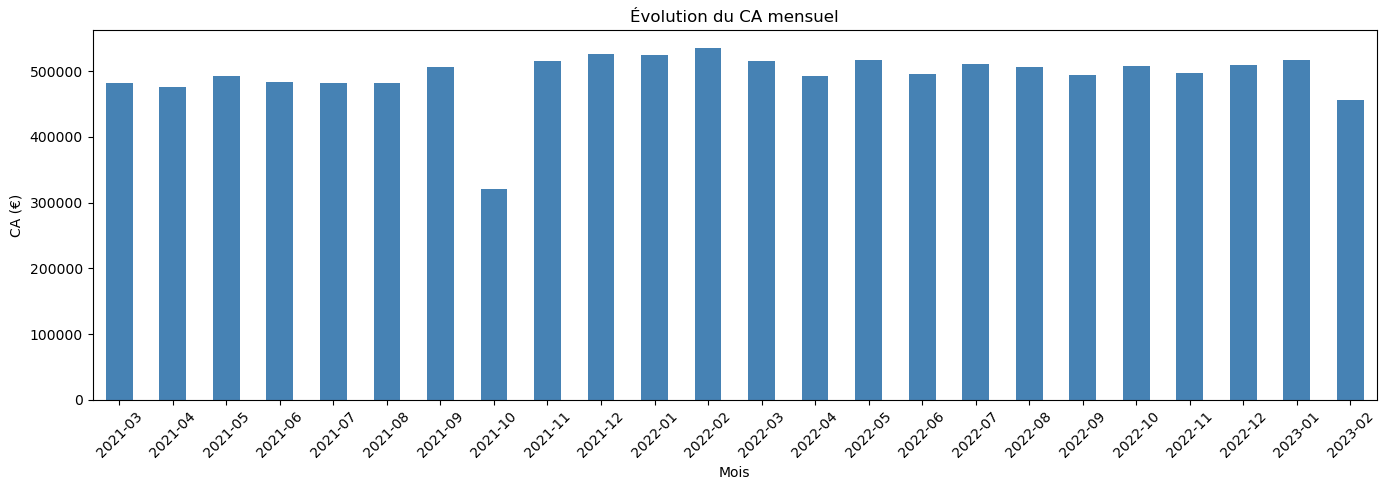

In [81]:
#graphique de l'évolution du CA mensuel
ca_mensuel.plot(kind='bar', figsize=(14, 5), color='steelblue', title="Évolution du CA mensuel")
plt.xlabel('Mois')
plt.ylabel('CA (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

L’évolution mensuelle du chiffre d’affaires montre une activité globalement stable autour de 500 000 € par mois.

Un pic est observé début 2022, suggérant une période particulièrement favorable.

En revanche, une baisse significative apparaît en octobre 2021, pouvant correspondre à un événement ponctuel.

Globalement, la stabilité du CA mensuel indique une base client relativement régulière et fidèle.

In [82]:
#chiffre d'affaires par catégorie
df.groupby('categ')['price'].sum()

categ
0    4419730.97
1    4653722.69
2    2780275.02
Name: price, dtype: float64

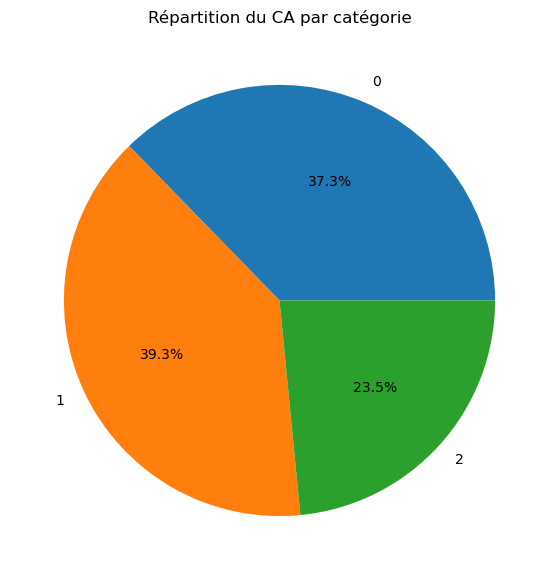

In [83]:
#graphique de la répartition du CA par catégorie
df.groupby('categ')['price'].sum().plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7),
                                         title='Répartition du CA par catégorie')
plt.ylabel('')
plt.show()

La répartition du chiffre d’affaires par catégorie montre que les catégories 0 et 1 génèrent à elles seules près de 77% du chiffre d’affaires total.

La catégorie 1 est la plus contributrice (39,3%), suivie de la catégorie 0 (37,3%).

La catégorie 2, plus chère en moyenne, se vend moins bien et représente 23,5% du CA total.

In [84]:
#nombre de ventes par catégorie
df.groupby('categ')['id_prod'].count()

categ
0    415459
1    227169
2     36483
Name: id_prod, dtype: int64

En volume, la catégorie 0 domine largement avec plus de 415 000 ventes, ce qui suggère qu’elle correspond à des produits à prix plus accessibles et à forte rotation.

La catégorie 2, en revanche, représente un faible volume de ventes mais contribue significativement au CA, confirmant son positionnement premium.

In [85]:
#top 10 des produits par CA
top10 = df.groupby('id_prod')['price'].sum().sort_values(ascending=False).head(10)
top10

id_prod
2_159    94893.50
2_135    69334.95
2_112    65407.76
2_102    60736.78
2_209    56971.86
1_395    54356.25
1_369    54025.48
2_110    53846.25
2_39     53060.85
2_166    52449.12
Name: price, dtype: float64

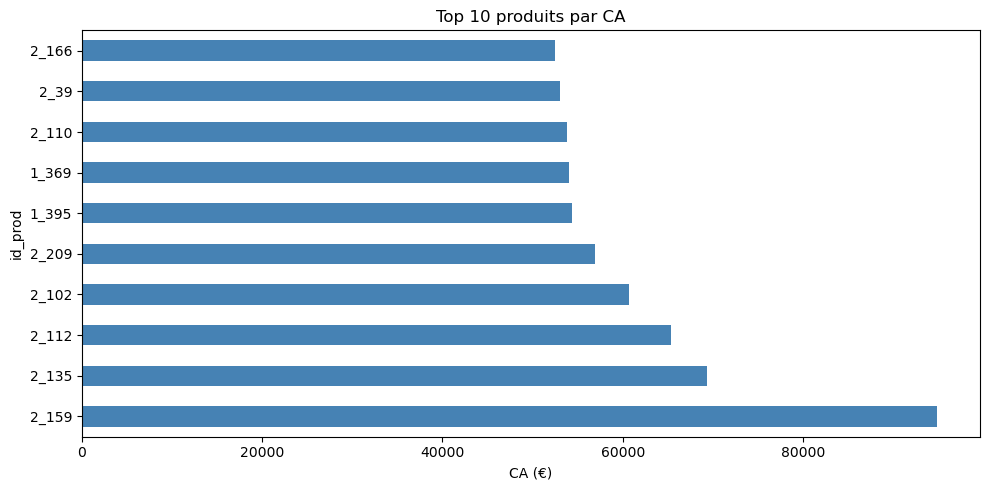

In [86]:
#graphique du top 10
top10.plot(kind='barh', figsize=(10, 5), color='steelblue', title='Top 10 produits par CA')
plt.xlabel('CA (€)')
plt.tight_layout()
plt.show()

Les 10 produits les plus performants génèrent chacun entre 50 000 € et 95 000 € de chiffre d’affaires.

Le produit 2_159 apparaît comme le best-seller en valeur.

Ces produits constituent des leviers stratégiques à maintenir en stock, mettre en avant sur le site et intégrer dans les campagnes marketing.

In [87]:
#flop 10 des produits par CA
flop10 = df.groupby('id_prod')['price'].sum().sort_values(ascending=True).head(10)
flop10

id_prod
0_1539    0.99
0_1284    1.38
0_1653    1.98
0_1601    1.99
0_807     1.99
0_541     1.99
0_1728    2.27
0_1498    2.48
0_898     2.54
0_1840    2.56
Name: price, dtype: float64

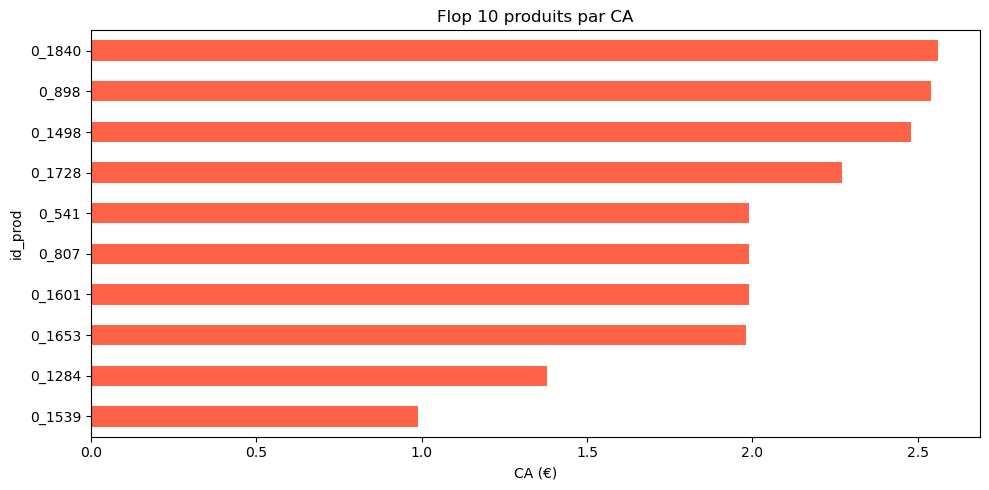

In [88]:
#graphique du flop 10
flop10.plot(kind='barh', figsize=(10, 5), color='tomato', title='Flop 10 produits par CA')
plt.xlabel('CA (€)')
plt.tight_layout()
plt.show()

Les produits les moins performants génèrent un chiffre d’affaires extrêmement faible, parfois inférieur à 3 €.

Une réflexion stratégique pourrait être menée sur leur maintien au catalogue ou leur repositionnement

In [89]:
#calcul pour l'analyse de Pareto
ca_par_produit = df.groupby('id_prod')['price'].sum().sort_values(ascending=False).reset_index()
ca_par_produit['cumul_pct'] = ca_par_produit['price'].cumsum() / ca_par_produit['price'].sum() * 100
ca_par_produit['pct_produits'] = (ca_par_produit.index + 1) / len(ca_par_produit) * 100
ca_par_produit

,id_prod,price,cumul_pct,pct_produits
0,2_159,94893.50,0.800537,0.030628
1,2_135,69334.95,1.385458,0.061256
2,2_112,65407.76,1.937249,0.091884
3,2_102,60736.78,2.449634,0.122511
4,2_209,56971.86,2.930258,0.153139
...,...,...,...,...
3260,0_1601,1.99,99.999947,99.877489
3261,0_807,1.99,99.999963,99.908116
3262,0_1653,1.98,99.999980,99.938744
3263,0_1284,1.38,99.999992,99.969372


In [90]:
#quelle proportion de produits génère 80% du CA ?
ca_par_produit[ca_par_produit['cumul_pct'] <= 80]['pct_produits'].max()

21.470137825421133

21.5% des produits génèrent 80% du chiffre d'affaires -> loi de Pareto vérifiée.

## Analyse des clients - Corrélations

In [263]:
# Calcul du CA total par client
top_clients = (
    df.groupby('client_id')['price']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_clients

client_id
c_1609    324033.35
c_4958    289760.34
c_6714    153598.92
c_3454    113637.93
c_3263      5276.87
c_1570      5271.62
c_2899      5214.05
c_2140      5208.82
c_7319      5155.77
c_7959      5085.45
Name: price, dtype: float64

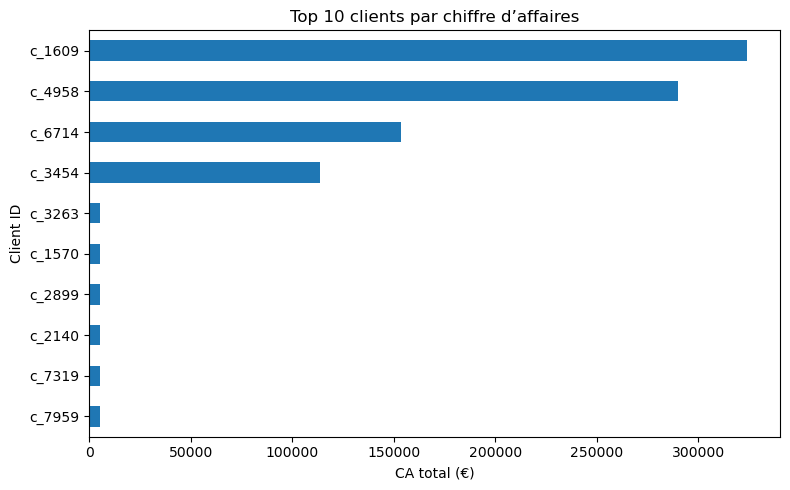

In [265]:
#Représentation des Top clients
plt.figure(figsize=(8,5))

top_clients.sort_values().plot(kind='barh')

plt.title('Top 10 clients par chiffre d’affaires')
plt.xlabel('CA total (€)')
plt.ylabel('Client ID')
plt.tight_layout()
plt.show()

Le graphique met en évidence une forte concentration du chiffre d’affaires sur un nombre très limité de clients.

Le client c_1609 génère à lui seul plus de 300 000 €, soit un niveau très supérieur aux autres clients.
Les trois clients suivants présentent également un chiffre d’affaires significativement plus élevé que le reste de la distribution.

À partir du 5ᵉ client, le chiffre d’affaires chute fortement, ce qui révèle une distribution très asymétrique :
une minorité de clients contribue de manière disproportionnée au chiffre d’affaires total. Ces clients sont peut être des professionnels qui achètent pour revendre ou pour exposer en bibliothèe, école et autres commerces.

Afin d’analyser plus pertinente la distribution du chiffre d’affaires pour la majorité des clients, les quatre clients les plus contributifs peuvent être temporairement exclus.

### Exclusion des du top 4 clients

In [276]:
# Identifier les 4 plus gros clients
top4_ids = top_clients.head(4).index
top4_ids

# Créer un dataset sans ces clients
ca_sans_top4 = ca_par_client[~ca_par_client['client_id'].isin(top4_ids)]

### Lien entre le genre et les catégories de livres achetés

In [95]:
#tableau de répartition du genre par catégorie
tableau_genre_categ = df.groupby(['sex', 'categ']).size().unstack(fill_value=0)
tableau_genre_categ

categ,0,1,2
sex,,,
f,206103,114899,17283
m,209356,112270,19200


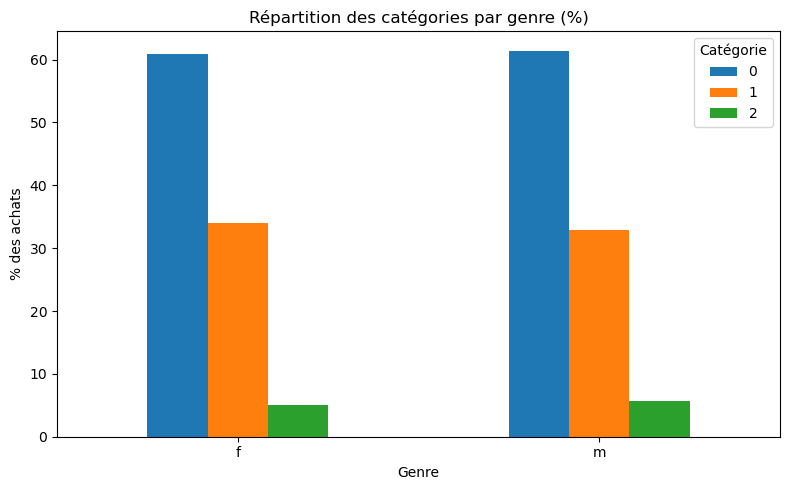

In [97]:
#graphique répartition des catégories par genre
tableau_genre_categ_pct = tableau_genre_categ.div(tableau_genre_categ.sum(axis=1), axis=0) * 100
tableau_genre_categ_pct.plot(kind='bar', figsize=(8, 5), title='Répartition des catégories par genre (%)')
plt.xlabel('Genre')
plt.ylabel('% des achats')
plt.xticks(rotation=0)
plt.legend(title='Catégorie')
plt.tight_layout()
plt.show()

La répartition des catégories achetées selon le genre montre des structures très similaires entre hommes et femmes.

Les deux segments privilégient majoritairement la catégorie 0 (environ 60%), suivie de la catégorie 1.

### Lien entre le genre et le montant total des achats

In [278]:
#calcul du CA total par client
ca_sans_top4 = df.groupby(['client_id', 'sex'])['price'].sum().reset_index()

In [280]:
#CA moyen par genre
ca_sans_top4.groupby('sex')['price'].mean()

sex
f    1308.257006
m    1454.512388
Name: price, dtype: float64

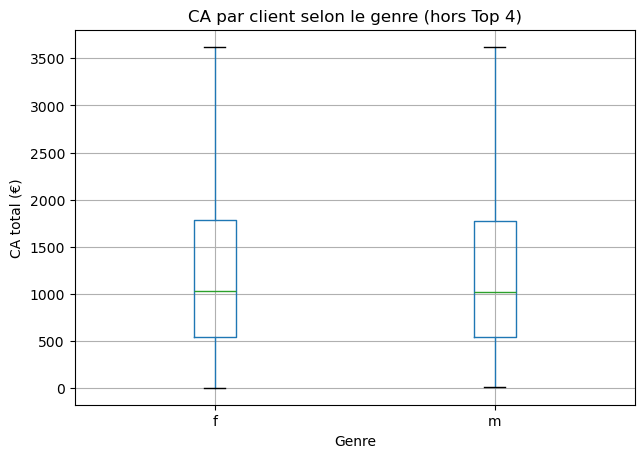

In [274]:
#graphique boxplot CA par genre
ca_sans_top4.boxplot(column='price', by='sex', figsize=(7,5), showfliers=False)

plt.title('CA par client selon le genre (hors Top 4)')
plt.suptitle('')
plt.xlabel('Genre')
plt.ylabel('CA total (€)')
plt.show()

L’étendue des valeurs est proche pour les deux genres

### Lien entre l'âge et la fréquence d'achat

In [286]:
#calcul de la fréquence d'achat et de l'âge moyen par client
freq_age = df.groupby('client_id').agg(
    frequence=('id_prod', 'count'),
    age=('age', 'first')
).dropna()
freq_age

,frequence,age
client_id,,
c_1,39,66
c_10,58,66
c_100,8,29
c_1000,125,55
c_1001,102,39
...,...,...
c_995,14,66
c_996,95,52
c_997,59,28


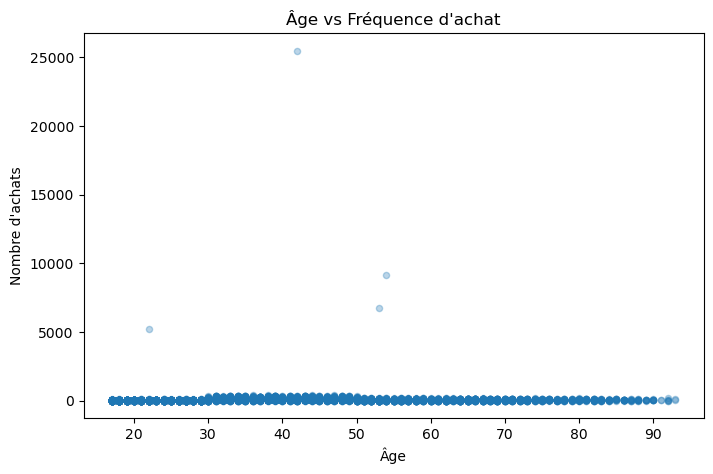

In [108]:
#graphique nuage de points age vs fréquence d'achat
freq_age.plot(kind='scatter', x='age', y='frequence', alpha=0.3, figsize=(8, 5),
              title="Âge vs Fréquence d'achat")
plt.xlabel('Âge')
plt.ylabel("Nombre d'achats")
plt.show()

In [291]:
#Nous analysons les fréquences d'achat sans les valeurs aberrantes
seuil_frequence = freq_age['frequence'].quantile(0.99)
freq_age_new = freq_age[freq_age['frequence'] <= seuil_frequence]

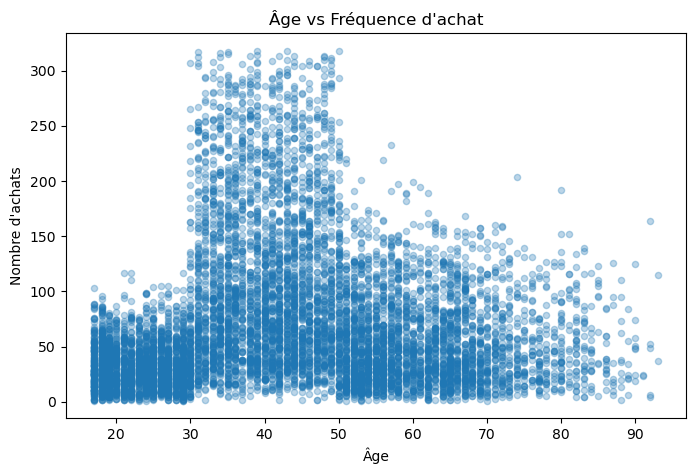

In [293]:
#graphique nuage de points age vs fréquence d'achat (new)
freq_age_new.plot(kind='scatter', x='age', y='frequence', alpha=0.3, figsize=(8, 5),
              title="Âge vs Fréquence d'achat")
plt.xlabel('Âge')
plt.ylabel("Nombre d'achats")
plt.show()

Les clients très jeunes (moins de 25 ans) semblent avoir une fréquence d’achat plus modérée, tandis que la tranche 30–50 ans présente des niveaux de fréquence plus élevés et plus dispersés.

Au-delà de 60 ans, la fréquence d’achat tend à diminuer progressivement.

Cela suggère que la population active (30–50 ans) constitue le segment le plus engagé en termes de récurrence d’achat.

### Lien entre l'âge et le panier moyen

In [111]:
#calcul du panier moyen et de l'âge par client
panier_age = df.groupby('client_id').agg(
    panier_moyen=('price', 'mean'),
    age=('age', 'first')
).dropna()
panier_age

,panier_moyen,age
client_id,,
c_1,14.312308,66
c_10,23.337931,66
c_100,31.856250,29
c_1000,18.095120,55
c_1001,17.773137,39
...,...,...
c_995,13.529286,66
c_996,17.111368,52
c_997,25.254407,28


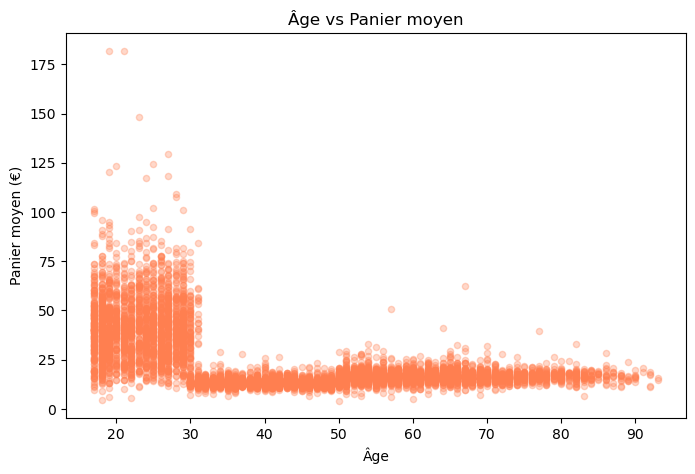

In [113]:
#graphique nuage de points age vs panier moyen
panier_age.plot(kind='scatter', x='age', y='panier_moyen', alpha=0.3, figsize=(8, 5),
                color='coral', title='Âge vs Panier moyen')
plt.xlabel('Âge')
plt.ylabel('Panier moyen (€)')
plt.show()

Les clients plus jeunes ont un panier moyen plus élevé. Cela s'explique par le fait que les jeunes achètent davantage de produits de catégorie 2 (beaux livres, prix élevés).

### Lien entre l'âge et la catégorie des livres achetés

In [116]:
#âge moyen par catégorie achetée
df.groupby('categ')['age'].mean()

categ
0    43.549250
1    47.353332
2    25.634761
Name: age, dtype: float64

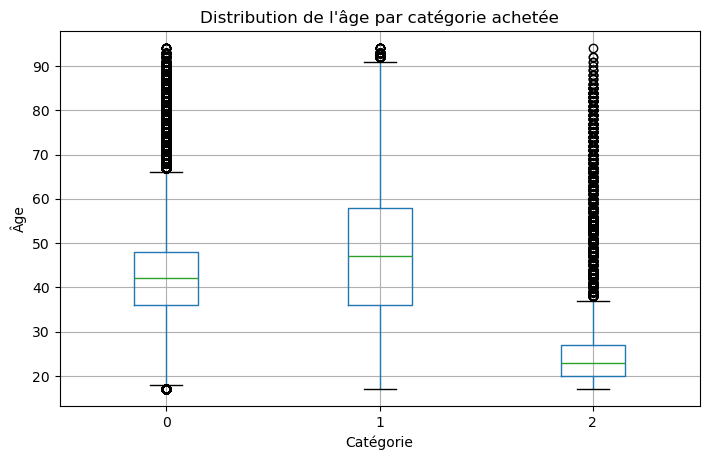

In [118]:
#graphique boxplot de l'âge par catégorie
df[['age', 'categ']].dropna().boxplot(column='age', by='categ', figsize=(8, 5))
plt.title("Distribution de l'âge par catégorie achetée")
plt.suptitle('')
plt.xlabel('Catégorie')
plt.ylabel('Âge')
plt.show()

La catégorie 2 est majoritairement achetée par une population plus jeune (médiane autour de 22–23 ans).
Les catégories 0 et 1 sont davantage consommées par des clients plus âgés (médiane entre 40 et 47 ans).
La catégorie 1 semble attirer la clientèle la plus âgée en moyenne.

Ces différences suggèrent que certaines catégories sont associées à des préférences générationnelles distinctes.

## 8. Recommandations marketing

**Mettre en place un programme VIP ciblant le top 5% des clients en valeur :**
Accès anticipé aux nouveautés, remises personnalisées, recommandations premium0

**Fidéliser les jeunes clients sur la catégorie 2 :**  
Les moins de 30 ans représentent les principaux acheteurs de beaux livres mais achètent moins souvent. Programme de fidélité, offres exclusives.

**Activer les clients seniors sur la catégorie 0 :**  
Les clients de 40-60 ans ont la fréquence d'achat la plus élevée sur les livres classiques. Newsletter régulière, recommandations personnalisées.

**Concentrer les efforts sur les best-sellers (Pareto) :**  
21.5% des produits génèrent 80% du CA. Mettre en avant ce catalogue en priorité et surveiller la rotation des produits à faible performance.

**Adapter les campagnes à la saisonnalité :**  
Identifier les pics mensuels du CA pour renforcer les budgets publicitaires aux bons moments (fêtes, rentrée).